In [ ]:
pip install tensorflow scikit-learn opencv-python


In [ ]:
import numpy as np
import cv2
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Extract features (images) and labels
X = lfw_people.images  # Shape: (n_samples, height, width)
y = lfw_people.target  # Shape: (n_samples,)

# Preprocess images: resize and normalize (0-1)
X = X[:, :, :, np.newaxis]  # Add channel dimension (grayscale)

X = X / 255.0  # Normalize images to [0, 1] range

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the data
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (1030, 50, 37, 1)
Test data shape: (258, 50, 37, 1)


In [ ]:
def build_model(input_shape):
    model = Sequential()

    # Convolutional Layer 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    # Convolutional Layer 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Convolutional Layer 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Flattening the output for fully connected layers
    model.add(Flatten())

    # Fully Connected Layer
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))  # Dropout to avoid overfitting

    # Output layer with softmax activation for multi-class classification
    model.add(Dense(len(np.unique(y)), activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Define the input shape (height, width, channels)
input_shape = (X_train.shape[1], X_train.shape[2], 1)

# Build the model
model = build_model(input_shape)
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 48, 35, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 24, 17, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 22, 15, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 11, 7, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 9, 5, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,871 (1.36 MB)

 Trainable params: 356,871 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.3750 - loss: 1.8412 - val_accuracy: 0.4612 - val_loss: 1.6055
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.4045 - loss: 1.7153 - val_accuracy: 0.4612 - val_loss: 1.5980
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4042 - loss: 1.7132 - val_accuracy: 0.4612 - val_loss: 1.5973
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.3746 - loss: 1.7444 - val_accuracy: 0.4612 - val_loss: 1.6122
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.4002 - loss: 1.7233 - val_accuracy: 0.4612 - val_loss: 1.6009
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.4128 - loss: 1.7075 - val_accuracy: 0.4612 - val_loss: 1.6115
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.4050 - loss: 1.7122 - val_accuracy: 0.4612 - val_loss: 1.6320
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.3894 - loss: 1.7235 - val_accuracy: 0.461

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5007 - loss: 1.5498
Test accuracy: 46.12%


In [ ]:
# Save the model to a file
model.save('lfw_face_recognition_model.h5')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


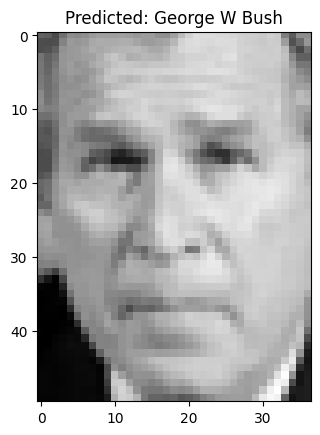

In [ ]:
# Predicting on the first image in the test set
import matplotlib.pyplot as plt

def predict_face(model, img, label_map):
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    return label_map[predicted_class]

# Create label map from target labels
label_map = {i: lfw_people.target_names[i] for i in range(len(lfw_people.target_names))}

# Predict on a test sample
sample_img = X_test[0]  # Take the first image from the test set
predicted_name = predict_face(model, sample_img, label_map)

# Show the image and predicted label
plt.imshow(sample_img.squeeze(), cmap='gray')  # Squeeze to remove extra channel dimension
plt.title(f"Predicted: {predicted_name}")
plt.show()
